In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space
import sympy as sym

# Exercise 11-1
- Residuals are orthogonal to the predicted data
- Make a scatterplot of the predicted data by the errors
- Compute the dot product and the correlation coefficient between the residuals and the model predicted data
- In theory both should be exactly zero

In [2]:
numcourses = np.array([13,4,12,3,14,13,12,9,11,7,13,11,9,2,5,7,10,0,9,7])
happiness  = np.array([70,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,70])

In [3]:
# design matrix as a column vector
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))

# fit the model using the left-inverse
X_leftinv = np.linalg.inv(X.T@X) @ X.T

In [4]:
# solve for the coefficients
beta = X_leftinv @ happiness
beta

array([23.13033815,  3.69820606])

In [5]:
pred_happiness = X @ beta

In [6]:
# Find residuals
res = happiness - pred_happiness
print(res @ pred_happiness)
coeff = np.corrcoef(res, pred_happiness)[0,1]
print(coeff)


-6.133404895081185e-11
-9.240510456164651e-17


Text(0.5, 1.0, 'Coefficient: -0.00000000000000009241')

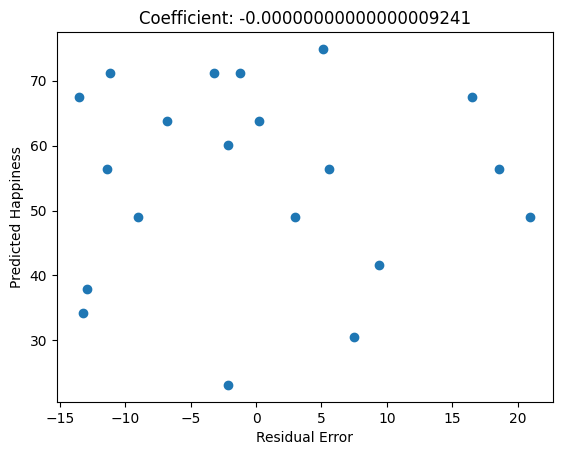

In [7]:
plt.scatter(x=res, y=pred_happiness)
plt.xlabel("Residual Error")
plt.ylabel("Predicted Happiness")
plt.title(f"Coefficient: {coeff:.20f}")

In [8]:
# should basically be zero (which it is)
res @ pred_happiness

np.float64(-6.133404895081185e-11)

# Exercise 11-2
- the model-predicted happiness is merely one way of linearly combining the columns of the design matrix
- the residuals vector isn't only orthogonal to that one linear weighted combination
- it is orthogonal to the entire subspace spanned by the design matrix

In [9]:
# compute the null space (via scipy.linalg)
nullspace = null_space(X.T)


# augment the residuals
nullspaceAugment = np.hstack( (nullspace,res.reshape(-1,1)) )


# print their ranks
print(f'dim(  N(X)    ) = {np.linalg.matrix_rank(nullspace)}')
print(f'dim( [N(X)|r] ) = {np.linalg.matrix_rank(nullspaceAugment)}')

dim(  N(X)    ) = 18
dim( [N(X)|r] ) = 18


# Exercise 11-3
- compute and compare the following
- the left inverse $(X^T X)^{-1} X^T y$
- the QR with inverse $R^{-1} Q^T y$
- the Gauss-Jordan elimination on the matrix $R$ augmented with $Q^T y$

In [10]:
# we already did 1) in problem 11-1 so jump to QR
Q, R = np.linalg.qr(X)
np.linalg.inv(R) @ Q.T @ np.array(happiness)

array([23.13033815,  3.69820606])

In [25]:
tmp = (Q.T @ happiness).reshape(-1, 1)
Raug = np.hstack((R, tmp))
Raug_rref = sym.Matrix(Raug).rref()[0]
Raug_rref

Matrix([
[  1, 0, 23.1303381489125],
[0.0, 1, 3.69820606445468]])

In [27]:
print(R)
print(Raug)
print(np.array(Raug_rref))

[[ -4.47213595 -38.23676242]
 [  0.          17.7468307 ]]
[[  -4.47213595  -38.23676242 -244.84944354]
 [   0.           17.7468307    65.63143693]]
[[1 0 23.1303381489125]
 [0.0 1 3.69820606445468]]


# Exercise 11-4
- Outliers are data values that are unusual or nonrepresentative and can cause significant problems in statistical models
- Change the first observed data point from 70 to 170, recompute the least squares fit and plot the data
- adjust the data back and plot again

In [59]:
happy_copy = happiness.copy()
happy_copy[0] = 170
happy_copy2 = happiness.copy()
happy_copy2[len(happiness)-1] = 170

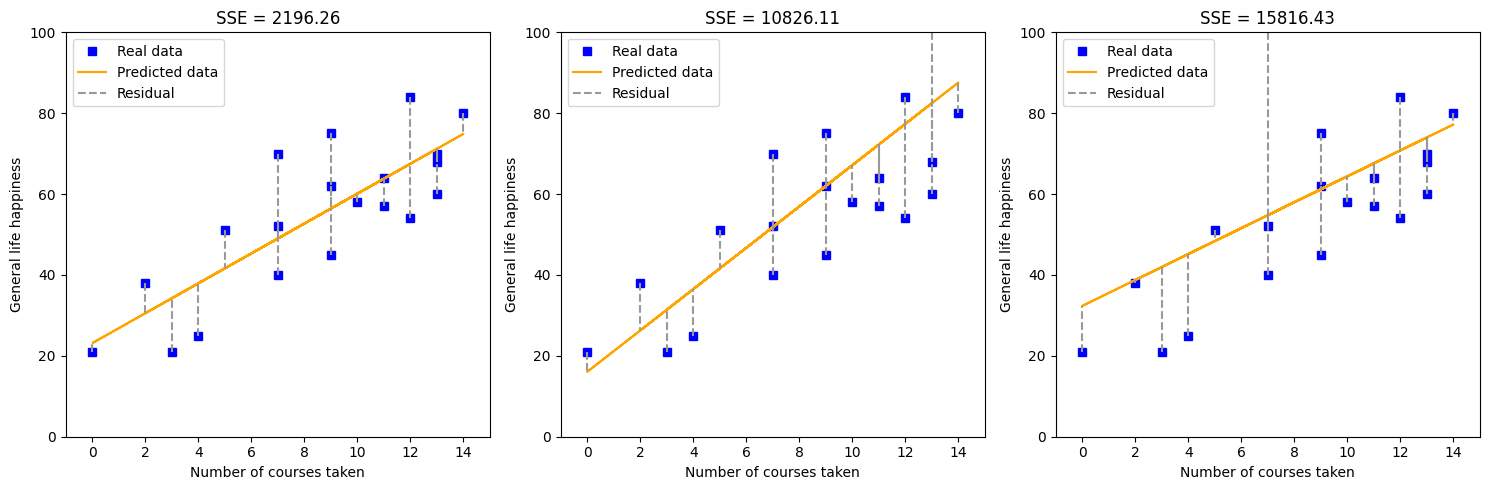

In [64]:
# we already have Q & R for X and so we just need to recalculate the coefficients for both
datasets = [happiness, happy_copy, happy_copy2]
qr_left = np.linalg.inv(R) @ Q.T

fig, axes = plt.subplots(1,len(datasets), figsize=(15,5))
for i, data in enumerate(datasets):
     beta = qr_left @ data
     pred_happiness = X @ beta
     axes[i].plot(numcourses, data, "bs")
     axes[i].plot(numcourses, pred_happiness, color="orange")
     for n, yy, yHat in zip(numcourses, data, pred_happiness):
         axes[i].plot([n,n], [yy, yHat], "--", color=[.6,.6,.6])

     axes[i].set(xlabel='Number of courses taken',ylabel='General life happiness',
          xlim=[-1,15],ylim=[0,100],xticks=range(0,15,2))
     axes[i].legend(['Real data','Predicted data','Residual'])
     axes[i].set_title(f'SSE = {np.sum((pred_happiness-data)**2):.2f}')
fig.tight_layout()

The outlier was the same change however the impact was different. This concept is called *leverage* and requires further reading into stats.

# Exercise 11-5
- compute the matrix inverse using least squares
- consider the equation $XB = Y$ where $X$ is the full-rank square matrix to invert, $B$ is the matrix of unknown coefficients and $Y$ is the observed data
- compute $B$ three ways
- use the left-inverse least squares method to compute the matrix one column at a time. This is done by computing the least squares fit between the matrix $X$ and each column of $Y$ in a for loop
- Use the left-inverse method to compute the entire $B$ matrix in one line of code
- Finally compute $X^{-1}$ using `np.linalg.inv()`
- Multiply each of those $B$ matrices by $X$ and show the figure

In [66]:
n = 6
X = np.random.default_rng().random((n, n))
Y = np.eye(n)

In [68]:
# left inverse least squares one column at a time
Xinv1 = np.zeros_like(X)
for coli in range(n):
  Xinv1[:,coli] = np.linalg.inv(X.T@X) @ X.T @ Y[:,coli]
Xinv1

array([[ 8.91978753e-03,  1.97419647e+01, -7.34260581e+00,
        -2.67330523e+00, -9.55659658e+00,  4.62987686e+00],
       [-3.33825996e-01,  5.83011338e-01,  1.16834257e+00,
         4.64292722e-01, -1.95687519e+00,  8.60231690e-01],
       [-7.33520451e-01, -5.09728919e+00,  1.68273421e+00,
         1.71921265e+00,  3.05384297e+00, -1.67781830e+00],
       [ 3.74038693e-01, -7.51253345e+00,  2.75733150e+00,
         7.31124445e-01,  3.23711684e+00, -2.72090021e-01],
       [ 2.24795650e+00, -1.46552024e+01,  3.47534682e+00,
         1.40536808e+00,  8.67205640e+00, -4.31353719e+00],
       [-1.98929965e+00,  5.89798874e+00, -4.79350973e-01,
        -8.58282472e-01, -2.62822517e+00,  7.82219476e-01]])

In [69]:
# do it in one line
Xinv2 = np.linalg.inv(X.T@X) @ X.T @ Y
Xinv2

array([[ 8.91978753e-03,  1.97419647e+01, -7.34260581e+00,
        -2.67330523e+00, -9.55659658e+00,  4.62987686e+00],
       [-3.33825996e-01,  5.83011338e-01,  1.16834257e+00,
         4.64292722e-01, -1.95687519e+00,  8.60231690e-01],
       [-7.33520451e-01, -5.09728919e+00,  1.68273421e+00,
         1.71921265e+00,  3.05384297e+00, -1.67781830e+00],
       [ 3.74038693e-01, -7.51253345e+00,  2.75733150e+00,
         7.31124445e-01,  3.23711684e+00, -2.72090021e-01],
       [ 2.24795650e+00, -1.46552024e+01,  3.47534682e+00,
         1.40536808e+00,  8.67205640e+00, -4.31353719e+00],
       [-1.98929965e+00,  5.89798874e+00, -4.79350973e-01,
        -8.58282472e-01, -2.62822517e+00,  7.82219476e-01]])

In [70]:
Xinv3 = np.linalg.inv(X)
Xinv3

array([[ 8.91978753e-03,  1.97419647e+01, -7.34260581e+00,
        -2.67330523e+00, -9.55659658e+00,  4.62987686e+00],
       [-3.33825996e-01,  5.83011338e-01,  1.16834257e+00,
         4.64292722e-01, -1.95687519e+00,  8.60231690e-01],
       [-7.33520451e-01, -5.09728919e+00,  1.68273421e+00,
         1.71921265e+00,  3.05384297e+00, -1.67781830e+00],
       [ 3.74038693e-01, -7.51253345e+00,  2.75733150e+00,
         7.31124445e-01,  3.23711684e+00, -2.72090021e-01],
       [ 2.24795650e+00, -1.46552024e+01,  3.47534682e+00,
         1.40536808e+00,  8.67205640e+00, -4.31353719e+00],
       [-1.98929965e+00,  5.89798874e+00, -4.79350973e-01,
        -8.58282472e-01, -2.62822517e+00,  7.82219476e-01]])

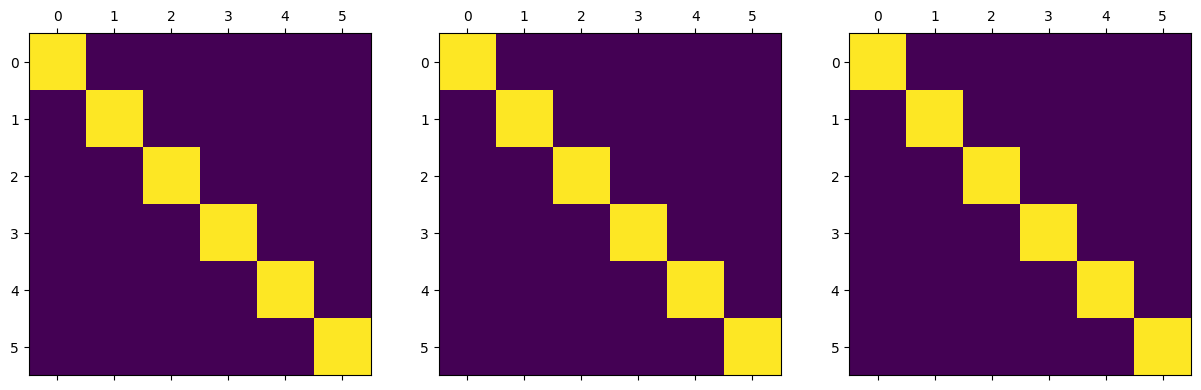

In [73]:
all_invs = [Xinv1, Xinv2, Xinv3]

fig, axes = plt.subplots(1,len(all_invs), figsize=(15,5))
for ax, X_inv in zip(axes, all_invs):
    ax.matshow(X_inv @ X)

In [79]:
print(Xinv1 - Xinv2)
print(Xinv2 - Xinv3)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
[[-3.16092638e-13 -2.60058641e-12  1.05959685e-12  4.03233003e-13
   1.19015908e-12 -6.78568313e-13]
 [ 1.52655666e-14 -1.36113343e-13  8.48210391e-14  2.21489493e-14
   9.19264664e-14 -3.18634008e-14]
 [ 6.89448498e-14  7.22089055e-13 -3.17523785e-13 -1.02140518e-13
  -3.34399175e-13  1.87849736e-13]
 [ 1.04305453e-13  9.18376486e-13 -3.79252185e-13 -1.28230759e-13
  -4.28990177e-13  2.45969911e-13]
 [ 1.52766688e-13  1.92557081e-12 -9.08606523e-13 -2.98872038e-13
  -1.03739239e-12  5.21360732e-13]
 [-7.06101844e-14 -7.02549130e-13  2.90600877e-13  1.06359366e-13
   3.35287353e-13 -2.01061390e-13]]
